In [21]:
# !pip install numpy pandas scikit-learn tensorflow matplotlib seaborn

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras import regularizers


In [22]:
Urls = ["https://github.com/yuliang419/football-predictor/blob/6d8b6b6ed2ad049012c8d3192146dde8e7a6de93/data/EPL_processed_results.csv?raw=true", 
        "https://raw.githubusercontent.com/yuliang419/football-predictor/6d8b6b6ed2ad049012c8d3192146dde8e7a6de93/data/EPL_Standings.csv?raw=true"]

def getCsv(csvUrl):
    df = pd.read_csv(csvUrl)

    if "results" in csvUrl :
        if "Unnamed: 0" in df.columns:
            df.rename(columns={"Unnamed: 0": "fixture_id"}, inplace=True)

    return df

df_matches = getCsv(Urls[0])
df_standings = getCsv(Urls[1])

# print("For results", df_matches.shape, df_matches.isnull().sum())
# print("For standings", df_standings.shape, df_standings.isnull().sum())


In [23]:
# Make a copy of the dataframe to keep things clean
df = df_matches.copy()

# Encode the FTR column
label_encoder = LabelEncoder()
df['FTR_encoded'] = label_encoder.fit_transform(df['FTR'])

# Check the mapping
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
# print("Label Encoding Mapping:", label_mapping)


In [24]:
feature_cols = [
    'HomeGoals','AwayGoals','StandingDiff', 'HomeWins', 'AwayWins', 'HomeDraws', 'AwayDraws',
    'AvgHomeGoals', 'AvgAwayGoals', 'AvgHomeShots', 'AvgAwayShots',
    'AvgHomeShotsOnTarget', 'AvgAwayShotsOnTarget', 'AvgHomeCorners',
    'AvgAwayCorners', 'AvgHomeGoalsConceded', 'AvgAwayGoalsConceded',
    'AvgHomeShotsConceded', 'AvgAwayShotsConceded'
]

X = df[feature_cols].values
y = df['FTR_encoded'].values

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
# can use a season-wise split

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

# scale features to help neural network
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

Training set size: (3064, 19)
Test set size: (767, 19)


In [26]:
def create_model(input_dim, num_classes, l2_lambda=0.001, dropout_rate=0.2):
    model = Sequential()
    
    # Hidden layer 1
    model.add(Dense(
        64, activation='relu',
        kernel_regularizer=regularizers.l2(l2_lambda),
        input_shape=(input_dim,)
    )) # hyperparameters
    model.add(Dropout(dropout_rate))
    
    # Hidden layer 2
    model.add(Dense(
        32, activation='relu',
        kernel_regularizer=regularizers.l2(l2_lambda)
    ))
    model.add(Dropout(dropout_rate))
    
    # Output layer
    model.add(Dense(num_classes, activation='softmax'))
    
    # Compile the model
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Number of classes = 3 (Home win, Draw, Away win)
num_classes = len(np.unique(y))
model = create_model(input_dim=X_train.shape[1], num_classes=num_classes)
model.summary()

# can use an other optimizer like batch normalization
# can use class weighting to balance outcomes

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 64)                1280      
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 dense_4 (Dense)             (None, 32)                2080      
                                                                 
 dropout_3 (Dropout)         (None, 32)                0         
                                                                 
 dense_5 (Dense)             (None, 3)                 99        
                                                                 
Total params: 3459 (13.51 KB)
Trainable params: 3459 (13.51 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [27]:
epochs = 30
batch_size = 32

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)


Epoch 1/30
96/96 [==============================] - 3s 8ms/step - loss: 0.9826 - accuracy: 0.5741 - val_loss: 0.7321 - val_accuracy: 0.7432
Epoch 2/30
96/96 [==============================] - 0s 5ms/step - loss: 0.6366 - accuracy: 0.7520 - val_loss: 0.4374 - val_accuracy: 0.9140
Epoch 3/30
96/96 [==============================] - 0s 4ms/step - loss: 0.4074 - accuracy: 0.8822 - val_loss: 0.2722 - val_accuracy: 0.9804
Epoch 4/30
96/96 [==============================] - 0s 4ms/step - loss: 0.2859 - accuracy: 0.9383 - val_loss: 0.1793 - val_accuracy: 0.9961
Epoch 5/30
96/96 [==============================] - 0s 5ms/step - loss: 0.2051 - accuracy: 0.9703 - val_loss: 0.1280 - val_accuracy: 1.0000
Epoch 6/30
96/96 [==============================] - 1s 5ms/step - loss: 0.1680 - accuracy: 0.9798 - val_loss: 0.1022 - val_accuracy: 1.0000
Epoch 7/30
96/96 [==============================] - 0s 4ms/step - loss: 0.1293 - accuracy: 0.9928 - val_loss: 0.0894 - val_accuracy: 1.0000
Epoch 8/30
96/96 [==

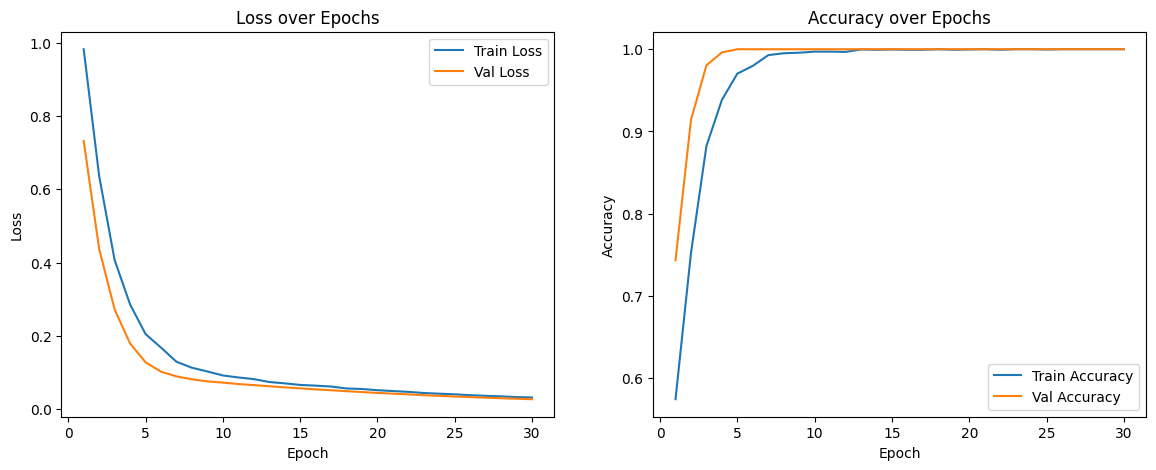

In [28]:
def plot_training_history(history):
    hist = history.history
    epochs_range = range(1, len(hist['loss']) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, hist['loss'], label='Train Loss')
    plt.plot(epochs_range, hist['val_loss'], label='Val Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, hist['accuracy'], label='Train Accuracy')
    plt.plot(epochs_range, hist['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.show()

plot_training_history(history)


In [29]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test Loss: {:.4f}".format(test_loss))
print("Test Accuracy: {:.2f}%".format(test_acc * 100))


Test Loss: 0.0270
Test Accuracy: 100.00%


24/24 [==============================] - 0s 2ms/step
Confusion Matrix:
 [[242   0   0]
 [  0 182   0]
 [  0   0 343]]


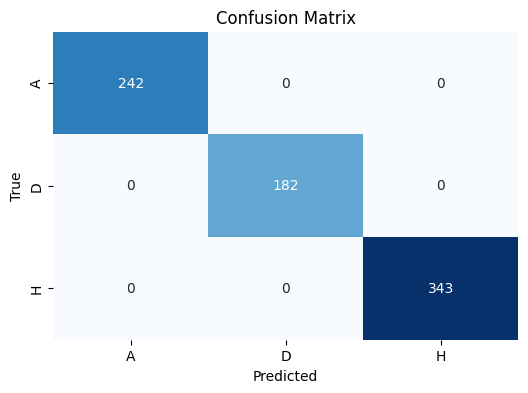

In [30]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# For better visual clarity:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [31]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Classification Report:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       242
           D       1.00      1.00      1.00       182
           H       1.00      1.00      1.00       343

    accuracy                           1.00       767
   macro avg       1.00      1.00      1.00       767
weighted avg       1.00      1.00      1.00       767



In [ ]:
new_data = df_matches.copy()

# Suppose new_data is a DataFrame with the same feature columns for future matches
new_data_scaled = scaler.transform(new_data[feature_cols].values)
predictions = model.predict(new_data_scaled)
predicted_classes = np.argmax(predictions, axis=1)

# Convert numeric predictions back to "H", "D", "A"
predicted_FTR = label_encoder.inverse_transform(predicted_classes)
new_data['Predicted_FTR'] = predicted_FTR

# save to csv
new_data.to_csv('results_predictions.csv', index=False)

print(new_data[['HomeTeam', 'AwayTeam', 'Predicted_FTR']])


120/120 [==============================] - 0s 3ms/step
         HomeTeam    AwayTeam Predicted_FTR
0         Arsenal   West Brom             H
1     Aston Villa     Norwich             H
2       Blackburn     Chelsea             A
3       Liverpool     Swansea             D
4      Man United  Sunderland             H
...           ...         ...           ...
3826      Everton   Newcastle             H
3827       Wolves       Leeds             A
3828  Aston Villa     Arsenal             A
3829    Leicester   Brentford             H
3830    Tottenham    West Ham             H

[3831 rows x 3 columns]
